# 5 — Latent-space distance to LGR5+ (Object A, scANVI)

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-08
* **Last modified date:** 2026-05-17

Distance from each population (fetal 1st-/2nd-trim Stem cells, adult Stem cells, enteroid Stem cells, TA, Enterocyte) to the LGR5+ centroid in scANVI latent space (Object A, human only). Three comparison axes: pooled, 1st trimester only, 2nd trimester only.

Per SPEC §3.3, every axis produces:
- Embedding panel (UMAP × cell_states / Study / LGR5+ highlight + 8 canonical SC marker UMAPs).
- Latent-distance bar (centroid distance + bootstrap CIs) + per-cell distance violin.

Distances are Euclidean in the scANVI latent. Each summary table is saved alongside its figure under `analysis_enhanced/figures/5_comparisons/`.


## 1. Imports & paths

In [1]:
import sys, gc
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

REPO     = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
DATA_OUT = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
FIG_DIR  = REPO / 'analysis_enhanced' / 'figures' / '5_comparisons'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO / 'analysis_enhanced'))
from _lgr5_common import (
    apply_style, embedding_panel, latent_distance_panel,
    assign_group, CONTRASTS, CANONICAL_SC_MARKERS,
    COMPARISON_GROUP_PALETTE,
)
apply_style()

/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version


/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## 2. Load integrated scANVI + align to raw Object A (full gene space)


In [2]:
scanvi = sc.read_h5ad(DATA_OUT / 'integrated_obj_a_scanvi.h5ad')
print('integrated_obj_a_scanvi:', scanvi.shape)

raw = sc.read_h5ad(DATA_OUT / 'object_a_human.h5ad')
print('object_a_human (raw):', raw.shape)

raw = raw[scanvi.obs_names].copy()
assert (raw.obs_names == scanvi.obs_names).all(), 'cell-id mismatch'

# Working AnnData: full gene space + scANVI obs/obsm
adata = ad.AnnData(
    X=raw.X,
    obs=scanvi.obs.copy(),
    var=raw.var.copy(),
    obsm={k: v for k, v in scanvi.obsm.items()},
)
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['lognorm'] = adata.X.copy()
adata.obs['comparison_group'] = assign_group(adata.obs)
print('\nworking adata:', adata.shape)
print('\ncomparison_group counts:')
print(adata.obs['comparison_group'].value_counts().to_dict())
del raw, scanvi; gc.collect()

integrated_obj_a_scanvi: (102013, 2000)


object_a_human (raw): (102460, 20112)



working adata: (102013, 20112)

comparison_group counts:
{'Enterocyte': 28523, 'Proximal progenitor': 26253, 'TA': 17730, 'Colonocyte': 13332, 'fetal_1tri_stem_cells': 3707, 'fetal_2tri_stem_cells': 3601, 'enteroid_stem_cells': 3439, 'adult_stem_cells': 2535, 'Goblet': 1631, 'BEST4+ epithelial': 469, 'Distal progenitor': 249, 'Secretory progenitor': 235, 'Stem cells': 201, 'LGR5+': 108}


7

## 3. UMAP from scANVI latent (recompute if missing or stale)


In [3]:
if 'X_umap' not in adata.obsm:
    sc.pp.neighbors(adata, use_rep='X_scanvi', n_neighbors=30)
    sc.tl.umap(adata, random_state=0, min_dist=0.3)
print('X_umap shape:', adata.obsm['X_umap'].shape)

X_umap shape: (102013, 2)


## 4. Per-axis analysis (pooled / 1st-trim / 2nd-trim)

For each axis: embedding panel + latent-distance bar+violin + summary CSV. The LGR5+ cells (Ishikawa, 108 cells) are kept in every axis so the reference centroid is defined.


In [4]:
AXES = {
    'pooled': adata.obs['age_group'].notna(),
    'first_trimester': (adata.obs['age_group'] == 'first trimester') | (adata.obs['lgr5_status'] == 'LGR5+'),
    'second_trimester': (adata.obs['age_group'] == 'second trimester') | (adata.obs['lgr5_status'] == 'LGR5+'),
}

all_summaries = {}
for axis, mask in AXES.items():
    mask = np.asarray(mask).astype(bool)
    sub = adata[mask].copy()
    print(f'\n=== axis: {axis} — {sub.n_obs:,} cells ===')
    # Embedding panel
    embedding_panel(
        sub, umap_key='X_umap',
        out_pdf=FIG_DIR / f'embedding__{axis}.pdf',
        title=f'Object A scANVI — {axis}',
        sc_genes=CANONICAL_SC_MARKERS,
        expression_layer='lognorm',
    )
    # Latent distance to LGR5+ centroid
    summary = latent_distance_panel(
        Z=sub.obsm['X_scanvi'],
        groups=sub.obs['comparison_group'],
        reference='LGR5+',
        out_pdf=FIG_DIR / f'latent_distance__{axis}.pdf',
        title=f'Latent distance to LGR5+ — {axis}',
    )
    summary.to_csv(FIG_DIR / f'latent_distance__{axis}.csv', index=False)
    all_summaries[axis] = summary
    display(summary)
    del sub; gc.collect()


=== axis: pooled — 102,013 cells ===


,group,n,centroid_dist,boot_mean,boot_ci_lo,boot_ci_hi,median_cell_dist
0,Stem cells,201,2.628705,2.635954,2.501922,2.781945,3.446570
1,fetal_2tri_stem_cells,3601,2.706701,2.706440,2.683115,2.732781,3.748755
2,fetal_1tri_stem_cells,3707,2.898115,2.898865,2.875386,2.921578,3.822018
3,enteroid_stem_cells,3439,2.987737,2.988454,2.966999,3.011493,3.802259
4,adult_stem_cells,2535,3.566234,3.566149,3.555207,3.576453,3.787159
5,Proximal progenitor,26253,3.959863,3.959790,3.953251,3.966249,4.564110
6,Distal progenitor,249,3.963631,3.971420,3.906342,4.047330,4.658405
7,TA,17730,4.764021,4.763776,4.750408,4.777412,5.580875
8,Enterocyte,28523,4.837190,4.836795,4.827568,4.845316,5.413476
9,Secretory progenitor,235,4.875913,4.888300,4.819675,4.974605,5.662098



=== axis: first_trimester — 39,422 cells ===


,group,n,centroid_dist,boot_mean,boot_ci_lo,boot_ci_hi,median_cell_dist
0,fetal_1tri_stem_cells,3707,2.898115,2.897668,2.875601,2.918998,3.822018
1,Distal progenitor,188,3.972718,3.976984,3.898411,4.052331,4.681406
2,Proximal progenitor,14441,4.021970,4.022373,4.012236,4.031880,4.691496
3,Enterocyte,11268,4.929832,4.929901,4.917407,4.944295,5.522352
4,TA,6603,4.963153,4.965040,4.946378,4.986121,5.744315
5,Colonocyte,3107,6.142132,6.143555,6.117103,6.169672,6.630809



=== axis: second_trimester — 24,421 cells ===


,group,n,centroid_dist,boot_mean,boot_ci_lo,boot_ci_hi,median_cell_dist
0,fetal_2tri_stem_cells,3601,2.706701,2.707024,2.683067,2.729759,3.748755
1,Proximal progenitor,2733,3.839562,3.840260,3.819078,3.863813,4.700078
2,TA,1685,4.906442,4.907327,4.856524,4.956326,5.872530
3,Enterocyte,9855,4.943445,4.944819,4.928706,4.962805,5.669449
4,Colonocyte,6426,6.131572,6.132240,6.117333,6.148760,6.617651


## 5. Combined headline view across axes


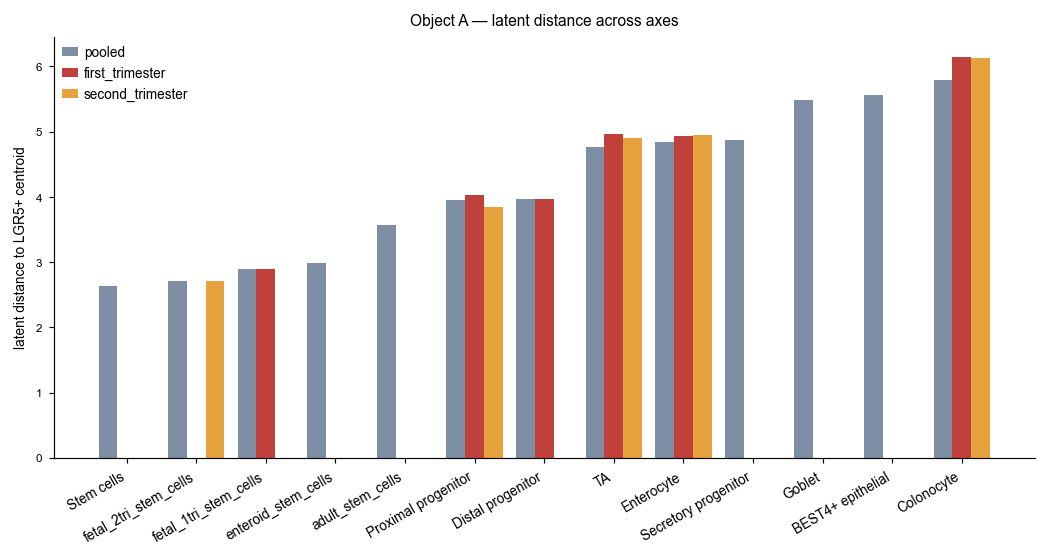

axis,pooled,first_trimester,second_trimester
group,,,
Stem cells,2.628705,NaN,NaN
fetal_2tri_stem_cells,2.706701,NaN,2.706701
fetal_1tri_stem_cells,2.898115,2.898115,NaN
enteroid_stem_cells,2.987737,NaN,NaN
adult_stem_cells,3.566234,NaN,NaN
Proximal progenitor,3.959863,4.021970,3.839562
Distal progenitor,3.963631,3.972718,NaN
TA,4.764021,4.963153,4.906442
Enterocyte,4.837190,4.929832,4.943445


In [5]:
combined = pd.concat([s.assign(axis=a) for a, s in all_summaries.items()], ignore_index=True)
combined.to_csv(FIG_DIR / 'latent_distance__combined.csv', index=False)

# Grouped bar — one row per population, three bars per row (axes)
ax_order = ['pooled', 'first_trimester', 'second_trimester']
pivot = (combined.pivot_table(index='group', columns='axis', values='centroid_dist')
                 .reindex(columns=ax_order))
pivot = pivot.sort_values('pooled')

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(pivot))
width = 0.27
for i, axis in enumerate(ax_order):
    vals = pivot[axis].values
    ax.bar(x + (i - 1) * width, vals, width, label=axis,
           color=['#7C8DA4', '#C0413B', '#E6A23C'][i], edgecolor='none')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=30, ha='right', fontsize=7)
ax.set_ylabel('latent distance to LGR5+ centroid', fontsize=7)
ax.legend(frameon=False, fontsize=7, loc='upper left')
ax.set_title('Object A — latent distance across axes', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'latent_distance__combined.pdf')
fig.savefig(FIG_DIR / 'latent_distance__combined.png', dpi=300)
plt.show()
display(pivot)

## 6. Done — outputs

Saved under `analysis_enhanced/figures/5_comparisons/`:
- `embedding__<axis>.{pdf,png}` — UMAP + canonical SC marker panel per axis.
- `latent_distance__<axis>.{pdf,png}` + `.csv` — distance bar + per-cell violin per axis.
- `latent_distance__combined.{pdf,png,csv}` — three-axis cross-comparison.
